# Notebook 1: Data Preparation
Reads IKB Excel directly. Creates 24 features. Splits train/test.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data from Excel

In [20]:
# Path to the Excel file in your project
# Change this if your folder structure is different
EXCEL_PATH = "../backend/data/IKB_overview_export_synthetic.xlsx"

raw = pd.read_excel(EXCEL_PATH)
print(f"Raw data: {len(raw)} rows")
print(f"Periods: {raw['period'].min()} to {raw['period'].max()}")
print(f"Departments: {sorted(raw['company_group'].unique())}")

# Aggregate to monthly totals per department
monthly = raw.groupby(["period", "company_group"])["amount_in_value"].sum().reset_index()
df = monthly.pivot(index="period", columns="company_group", values="amount_in_value").fillna(0)
df.index = pd.to_datetime(df.index, format="%Y-%m")
df = df.sort_index()
df["Total"] = df.sum(axis=1)

print(f"\nMonthly data: {len(df)} months x {df.shape[1]} columns")
print(f"Range: {df.index.min().strftime('%Y-%m')} to {df.index.max().strftime('%Y-%m')}")
df.head()

Raw data: 500 rows
Periods: 2020-01 to 2025-11
Departments: ['CX', 'ECX', 'Marketing', 'Recruitment', 'Sales', 'Support']

Monthly data: 71 months x 7 columns
Range: 2020-01 to 2025-11


company_group,CX,ECX,Marketing,Recruitment,Sales,Support,Total
period,,,,,,,
2020-01-01,0.00,1571.11,320.48,671.72,0.0,1496.52,4059.83
2020-02-01,1552.47,2592.04,1372.15,0.00,0.0,0.00,5516.66
2020-03-01,0.00,195.33,159.64,632.19,335.5,797.16,2119.82
2020-04-01,1695.84,0.00,1208.96,0.00,0.0,2533.40,5438.20
2020-05-01,0.00,728.77,458.03,1078.10,0.0,648.87,2913.77


## 2. Inspect

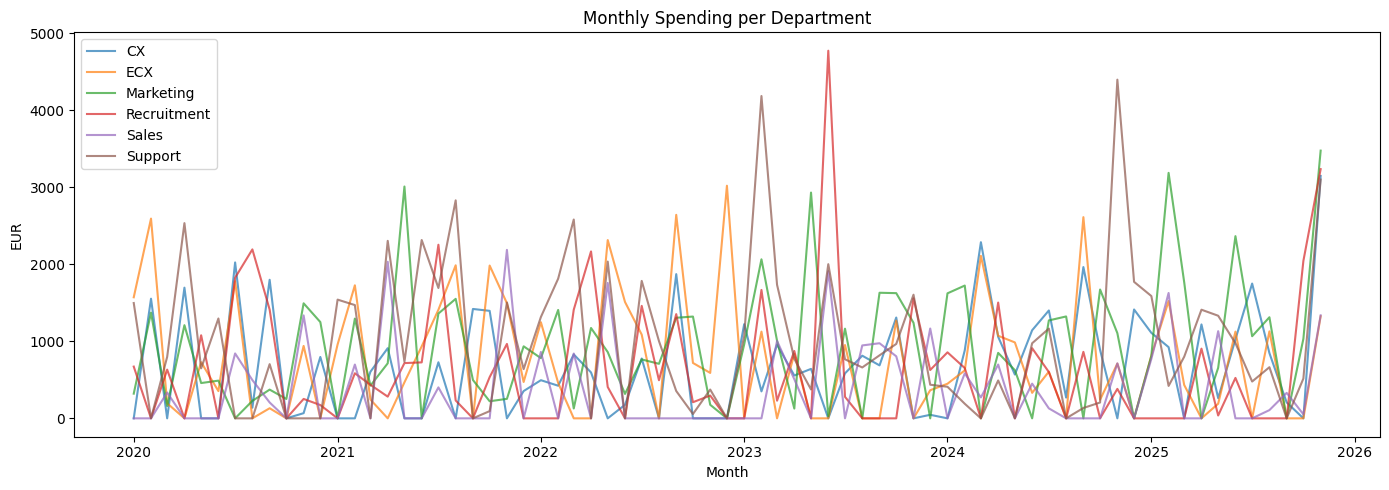

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
for col in [c for c in df.columns if c != "Total"]:
    ax.plot(df.index, df[col], label=col, alpha=0.7)
ax.set_xlabel("Month")
ax.set_ylabel("EUR")
ax.set_title("Monthly Spending per Department")
ax.legend()
plt.tight_layout()
plt.show()

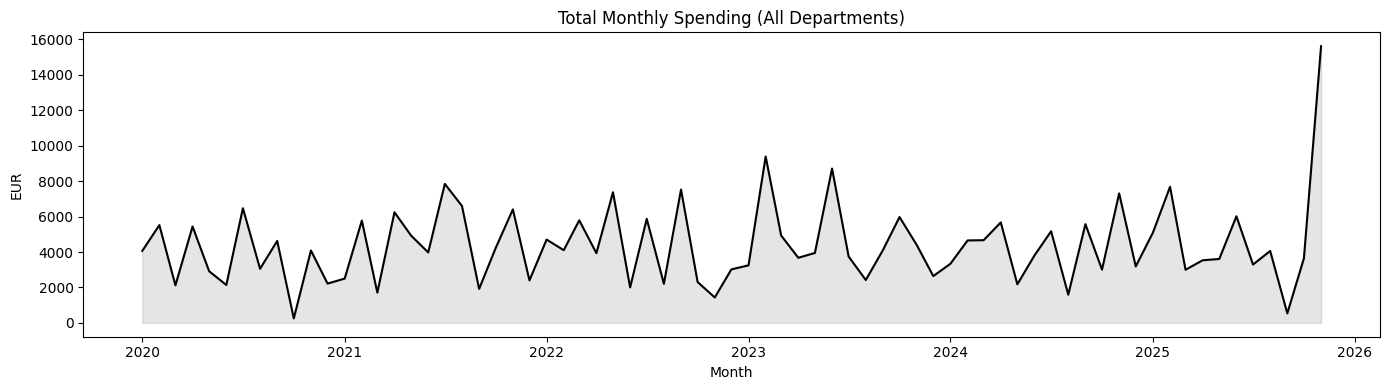

In [22]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["Total"], color="black", linewidth=1.5)
ax.fill_between(df.index, df["Total"], alpha=0.1, color="black")
ax.set_xlabel("Month")
ax.set_ylabel("EUR")
ax.set_title("Total Monthly Spending (All Departments)")
plt.tight_layout()
plt.show()

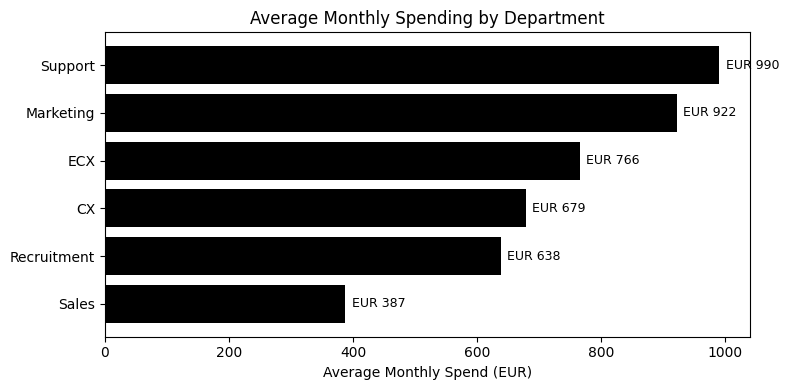

In [23]:
avg = df.drop(columns="Total").mean().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(avg.index, avg.values, color="black")
ax.set_xlabel("Average Monthly Spend (EUR)")
ax.set_title("Average Monthly Spending by Department")
for i, v in enumerate(avg.values):
    ax.text(v + 10, i, f"EUR {v:.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Feature Engineering (24 features, 12-month lookback)

In [24]:
depts = [c for c in df.columns if c != "Total"]
DEPT_MAP = {d: i for i, d in enumerate(sorted(depts))}
rows = []

for dept in depts:
    s = df[dept].values
    dates = df.index
    
    for i in range(12, len(s)):
        ytd = sum(s[j] for j in range(i) if dates[j].year == dates[i].year)
        
        rows.append({
            "department": dept,
            "date": dates[i],
            "month": dates[i].month,
            "year": dates[i].year,
            "lag_1": s[i-1], "lag_2": s[i-2], "lag_3": s[i-3],
            "rolling_avg_3": np.mean(s[i-3:i]),
            "trend": s[i-1] - s[i-2],
            "ytd_spend": ytd,
            "dept_code": DEPT_MAP[dept],
            "lag_4": s[i-4], "lag_5": s[i-5], "lag_6": s[i-6],
            "rolling_avg_6": np.mean(s[i-6:i]),
            "rolling_avg_12": np.mean(s[i-12:i]),
            "rolling_std_3": np.std(s[i-3:i]),
            "rolling_std_6": np.std(s[i-6:i]),
            "rolling_min_3": np.min(s[i-3:i]),
            "rolling_max_3": np.max(s[i-3:i]),
            "rolling_range_3": np.max(s[i-3:i]) - np.min(s[i-3:i]),
            "same_month_last_year": s[i-12],
            "acceleration": (s[i-1] - s[i-2]) - (s[i-2] - s[i-3]),
            "pct_change_1": ((s[i-1] - s[i-2]) / s[i-2] * 100) if s[i-2] != 0 else 0,
            "ratio_to_avg": s[i-1] / np.mean(s[:i]) if np.mean(s[:i]) != 0 else 1,
            "quarter": (dates[i].month - 1) // 3 + 1,
            "spend": s[i],
        })

ml_df = pd.DataFrame(rows)
print(f"ML dataset: {len(ml_df)} rows, {len([c for c in ml_df.columns if c not in ['department','date','spend']])} features")

ML dataset: 354 rows, 24 features


## 4. Define X and y

In [25]:
feature_cols = [c for c in ml_df.columns if c not in ["department", "date", "spend"]]
X = ml_df[feature_cols]
y = ml_df["spend"]
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Target: min=EUR {y.min():.0f}, max=EUR {y.max():.0f}, mean=EUR {y.mean():.0f}")

Features (24): ['month', 'year', 'lag_1', 'lag_2', 'lag_3', 'rolling_avg_3', 'trend', 'ytd_spend', 'dept_code', 'lag_4', 'lag_5', 'lag_6', 'rolling_avg_6', 'rolling_avg_12', 'rolling_std_3', 'rolling_std_6', 'rolling_min_3', 'rolling_max_3', 'rolling_range_3', 'same_month_last_year', 'acceleration', 'pct_change_1', 'ratio_to_avg', 'quarter']
Target: min=EUR 0, max=EUR 4771, mean=EUR 758


## 5. Train / Test Split (time-based)

In [26]:
split_date = "2025-06-01"
train_mask = ml_df["date"] < split_date
test_mask = ml_df["date"] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]
test_info = ml_df[test_mask][["department", "date"]].reset_index(drop=True)

print(f"Train: {len(X_train)} rows (before {split_date})")
print(f"Test:  {len(X_test)} rows ({split_date} onward)")
print("\nReady for Notebook 2.")

Train: 318 rows (before 2025-06-01)
Test:  36 rows (2025-06-01 onward)

Ready for Notebook 2.
